In [1]:
import actipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from numpy.lib.stride_tricks import sliding_window_view
from scipy.signal import butter, filtfilt, get_window, stft
from scipy.fft import rfft, irfft, rfftfreq, next_fast_len
from scipy.ndimage import binary_opening, binary_closing

# Reading an actigraphy file

The actigraphy data we worked with comes from a tri-axial wrist-worn accelerometer. This includes three sequences of acceleration measured in $g$-force along the three axes relative to the face of the wristwatch. Using `actipy`, we can parse the raw data into a dataframe. Optionally we can combine the three sequences into one sequence of total acceleration. Below is an example on some test data.

In [2]:
# Read the raw actigraphy with actipy
df, info = actipy.read_device("test_data/actigraphy_run.bin", lowpass_hz=None, calibrate_gravity=True, detect_nonwear=False, verbose=False)
SR = int(info["SampleRate"])

# Compute the overall acceleration metric (ENMO)
df["accel"] = np.sqrt(df.x**2 + df.y**2 + df.z**2) - 1

# (Optional) Extracting hours and minutes for plotting purposes
df["hour"] = df.index.map(lambda x: x.hour)
df["minute"] = df.index.map(lambda x: x.minute)
df = df[df.hour == 11] # Cropping to 11am-12pm as an example for this data

# Display some data
print(f"Device: {info['Device']}")
print(f"Sampling rate: {SR}Hz")
display(df.head())

Device: GENEActiv
Sampling rate: 30Hz


,x,y,z,temperature,accel,hour,minute
time,,,,,,,
2024-06-03 11:00:00.000000000,0.080757,0.537345,-0.227475,27.1,-0.410928,11,0
2024-06-03 11:00:00.033333333,0.064678,0.485505,-0.203211,27.1,-0.469724,11,0
2024-06-03 11:00:00.066666666,-0.011698,0.421701,-0.178947,27.1,-0.541753,11,0
2024-06-03 11:00:00.100000000,-0.116212,0.425689,-0.166815,27.1,-0.528255,11,0
2024-06-03 11:00:00.133333333,-0.248864,0.250229,-0.207255,27.1,-0.590729,11,0


For reference, this is what the acceleration looks like over the course of an hour. For this test example, the wearer was performing set tasks on a schedule:

- 11:00 - standing around talking
- 11:10 - walking slowly
- 11:20 - sitting
- 11:30 - walking quickly
- 11:40 - standing around talking
- 11:50 - playing Ninja (fast-paced, erratic playground game)

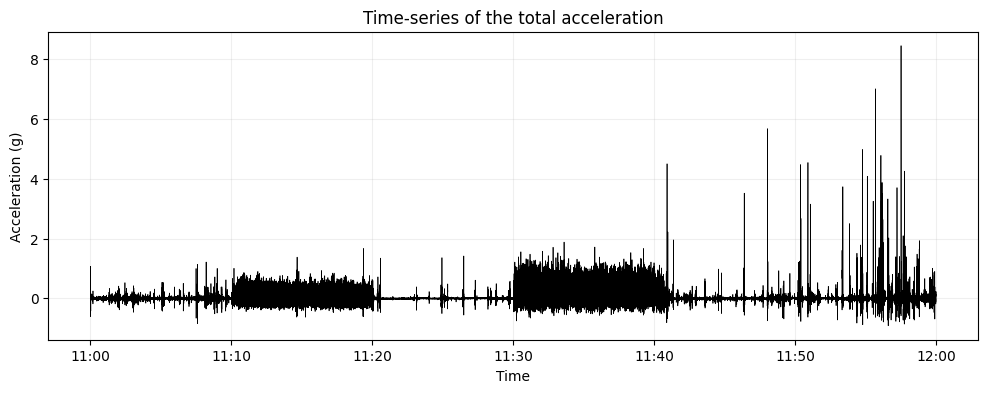

In [3]:
# Plotting
fig,ax = plt.subplots(figsize=(12,4))
ax.plot(df.index, df.accel, c="k", linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title("Time-series of the total acceleration")
ax.set_xlabel("Time")
ax.set_ylabel("Acceleration (g)")
ax.grid(alpha=0.2)
plt.show()

# Walking detection

For the purpose of analyzing psychomotor rhythm and its relationship with depression/treatment outcomes, we wished to automatically detect walking bouts from actigraphy. From there, we would be able to use properties of those walking bouts as predictors, for example, bout length median \& variance, and cadence median \& variance (cadence referring to the speed of the steps). The main idea towards this was to use Fourier analysis to identify periods of time with highly consistent oscillation.

## Attempt 1: spectral analysis (what didn't work)

Using the short-time Fourier transform (STFT), we can compute which frequencies the signal is made up of for small time windows across the collection period.

In [4]:
# Short-time Fourier transform
f, t, Zxx = stft(df["accel"], fs=SR, window="hann", nperseg=512, noverlap=512//4*3)
t = pd.to_datetime(t, unit="s") + pd.Timedelta(hours=11) # Convert to nice datetime for plotting
Zxx = abs(Zxx[:,:])

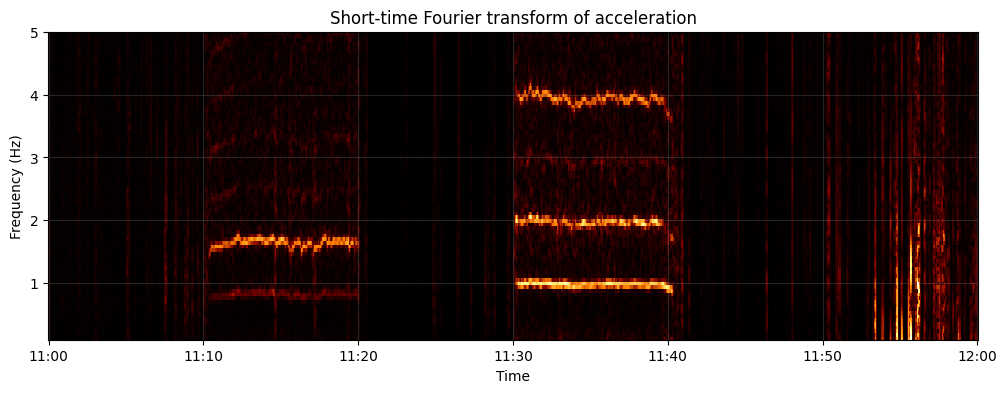

In [5]:
fig,ax = plt.subplots(figsize=(12,4))
ax.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=0.2, cmap="afmhot")
ax.set_ylim(0.1,5.0)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title("Short-time Fourier transform of acceleration")
ax.set_xlabel("Time")
ax.set_ylabel("Frequency (Hz)")
ax.grid(alpha=0.2)
plt.show()

Given this, it should not be hard to find walking bouts, since we can try isolating windows of time where the derived frequencies are strong and reasonably steady. When the wearer is not walking, or performing other erratic activities, the Fourier transform is extremely unlikely to produce stable, strong frequencies.

However, it became immediately clear that it would be non-trivial to determine the wearer's actual cadence, since even during the walking bouts, the Fourier transform produces several harmonics. For example, in the scheduled walking times from 11:10am-11:20am and 11:30am-11:40am, which of these strong underlying frequencies actually corresponds to the true walking speed? It's not particularly important which harmonic we identify since it will simply scale all our measurements by a fixed multiple, but we must be careful to use a method that doesn't spuriously identify different harmonics in different bouts. If we naively decided to extract the strongest frequency at any given time, in the above example, the slow walking would come out to ~1.7Hz and the fast walking would come out to ~1.0Hz, which is clearly contradictory.

## Attempt 2: cepstral analysis (what did work)

This method is much more involved than STFT, but aims to address its issues. A common use of cepstral analysis is to identify the pitch of a person's voice in speech, which also consists of a complex, harmonic structure, rather than a simple sine wave.

The intuition is this: during the walking periods, we see the presence of several distinct frequencies, some strong and some faint. However, we can generally assume there is only one single source that contributes meaningfully to the signal during these times, which is the oscillation due to walking. This will always give rise to a single lowest frequency (the fundamental $f$), and all other frequencies can only be multiples of that (harmonics $2f, 3f,...$). Therefore, we can estimate $f$ by leveraging the fact that the frequencies that appear to be present have a spacing of $f$. The goal of cepstral analysis is to compute the spacing that agrees best with the actual combination of fundamental and harmonics in the signal. This even allows us to estimate the fundamental in the case where a signal has only harmonics and the fundamental is physically not present.

### Main code backbone

In [ ]:
def cepstral_walk_score(
    x, y, z, sr,
    win_sec=10.0,
    hop_sec=2.0,
    window_type="hann",
    q_target_band=(0.3, 4.0),
    f0_target_band=(1.1, 3.0),
    harm_K=3,
    harm_bw_hz=0.2,
    smooth_frames=30,
    smooth_f0_log_k=10,
):
    """
    Cepstral walk score and cadence estimation.

    Parameters
    ----------
    x : array_like
        Acceleration (g) in the x-axis.
    y : array_like
        Acceleration (g) in the y-axis.
    z : array_like
        Acceleration (g) in the z-axis.
    sr : int
        The sampling rate of the sequences x, y, and z.
    win_sec : float
        The window width for FFT.
    hop_sec : float
        The window hop size for FFT.
    window_type : str
        Any window type that would be accepted by scipy.signal.get_window()
    q_target_band : tuple[float, float]
        The lower and upper bound of desired quefrencies to detect during cepstral analysis.
    f0_target_band : tuple[float, float]
        The lower and upper bound of desired frequencies to detect during the refining step.
    harm_K : int
        The number of harmonics to consider during the refining step.
    harm_bw_hz : float
        The bandwidth used for summation around each harmonic during the refining step.
    smooth_frames : int
        Number of frames to use for median filtering of the walking score in the smoothing step.
    smooth_f0_log_k : int
        Number of frames to use for median filtering of the cadence in the smoothing step.

    Returns
    -------
    scores : ndarray
        Array containing a walking score for each frame based on the harmonic ratio (higher is more likely walking).
    f0s : ndarray
        Array containing the estimated cadence for each frame, or NaN when none is identified.
    times : ndarray
        Array containing the center of each frame in seconds.
    """

    ##### PRE-PROCESSING #####

    # Ensure arrays and sizes
    dt = np.float32
    x = np.asarray(x, dt); y = np.asarray(y, dt); z = np.asarray(z, dt)
    n = min(len(x), len(y), len(z))
    n_win = int(round(win_sec * sr))
    n_hop = int(round(hop_sec * sr))
    if n < n_win:
        raise ValueError("Signal shorter than window")
    
    # Prepare array window views
    Xf = sliding_window_view(x[:n], n_win)[::n_hop]
    Yf = sliding_window_view(y[:n], n_win)[::n_hop]
    Zf = sliding_window_view(z[:n], n_win)[::n_hop]
    n_frames = Xf.shape[0]

    # Windowed de-meaning
    w = get_window(window_type, n_win, fftbins=True).astype(dt)
    Xf = (Xf - Xf.mean(axis=1, keepdims=True)) * w
    Yf = (Yf - Yf.mean(axis=1, keepdims=True)) * w
    Zf = (Zf - Zf.mean(axis=1, keepdims=True)) * w

    # Compute center of each frame
    starts = np.arange(0, n - n_win + 1, n_hop)
    times = (starts + 0.5 * n_win) / sr


    ##### CEPSTRAL ANALYSIS #####

    n_fft = next_fast_len(n_win)

    # Step 1a: Take the Fourier transform (separated axes)
    Xx = rfft(Xf, n=n_fft, axis=1, workers=True)
    Xy = rfft(Yf, n=n_fft, axis=1, workers=True)
    Xz = rfft(Zf, n=n_fft, axis=1, workers=True)

    # Step 1b: Combine separated axes into a single spectrum
    P = (np.abs(Xx)**2 + np.abs(Xy)**2 + np.abs(Xz)**2) / (n_win**2)
    f = rfftfreq(n_fft, 1/sr)

    # Step 2: Log-transform
    L = 10.0 * np.log10(np.maximum(P, 1e-6))

    # Step 3: Inverse Fourier transform
    C = irfft(L, n=n_fft, axis=1, workers=True)
    
    
    ##### POST-PROCESSING #####

    # Step 1: Mask out low and high quefrencies
    q = np.arange(n_fft, dtype=dt) / sr # List of detectable quefrencies
    qmask = (q >= dt(q_target_band[0])) & (q <= dt(q_target_band[1])) # Hard bandpass
    if not np.any(qmask):
        # Nothing to search; return NaNs
        scores = np.zeros(n_frames, dtype=dt)
        f0s = np.full(n_frames, np.nan, dtype=dt)
        return scores, f0s, times
    
    # Step 2: Generate walking score based on relative ratio of strongest
    # candidate quefrency using the entire signal as a reference
    Cb = C[:, qmask]
    med = np.median(Cb, axis=1)
    mad = np.median(np.abs(Cb - med[:, None]), axis=1) # Median absolute deviation
    scale = np.maximum(mad, dt(0.02))
    idx_rel = np.argmax(Cb, axis=1)
    peak = Cb[np.arange(n_frames), idx_rel]
    scores = np.maximum(0.0, (peak - med) / (scale + dt(1e-6))).astype(dt)

    # Step 3: Convert quefrencies to frequencies
    q_idx = np.flatnonzero(qmask)[0] + idx_rel
    periods = q[q_idx]
    f0s = (1.0 / periods).astype(dt)

    # Step 4a: Refining result by explicitly checking nearby multiples
    # for increased power within a small bandwidth
    def _band_sum(P_row, f0, K, f, bw_bins):
        if not (np.isfinite(f0) and f0 > 0):
            return -np.inf
        acc = 0.0
        for k in range(1, K+1):
            fk = k * f0
            if fk < f[0] or fk > f[-1]:
                continue
            j = np.searchsorted(f, fk)
            lo = max(0, j - bw_bins); hi = min(len(f), j + bw_bins + 1)
            acc += P_row[lo:hi].sum()
        return acc

    lo, hi = f0_target_band
    df = f[1] - f[0] # FFT window bandsize
    bw_bins = max(1, int(round(harm_bw_hz / df))) # number of neighbouring bins to sum
    for i in range(n_frames):
        f0 = float(f0s[i])
        cands = [g*f0 for g in (0.5, 1.0, 2.0) if lo <= g*f0 <= hi]
        if not cands:
            f0s[i] = np.nan
            continue
        sums = [_band_sum(P[i], fc, harm_K, f, bw_bins) for fc in cands]
        f0s[i] = cands[int(np.argmax(sums))]

    # Step 4b: Final refinement by smoothing
    if smooth_frames and smooth_frames > 1:
        scores = _median_filter_1d(scores, int(smooth_frames))
    if smooth_f0_log_k and smooth_f0_log_k > 1:
        f0s = _smooth_log_f0(f0s, int(smooth_f0_log_k))

    return scores, f0s, times


def butter_bandpass_filter(x, sr, lowcut=0.3, highcut=10.0, order=4):
    """
    Apply a butterworth bandpass filter to a signal.

    Parameters
    ----------
    x : ndarray
        The input array.
    sr : int
        The sampling rate.
    lowcut : float
        The lower range of the bandpass filter.
    highcut : float
        The upper range of the bandpass filter.
    order : int
        The order of the butterworth filter.

    Returns
    -------
    y : ndarray
        The filtered array.
    """
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, x)
    return y


def _median_filter_1d(x, k):
    """
    Median filter (edge padded) for 1D arrays.

    Parameters
    ----------
    x : ndarray
        The input array.
    k : int
        The size of the moving window.

    Returns
    -------
    out : ndarray
        The filtered array.
    """
    if k <= 1 or x.size == 0:
        return x
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    out = np.empty_like(xp[pad:-pad])
    for i in range(len(out)):
        out[i] = np.median(xp[i:i+k])
    return out


def _smooth_log_f0(f0, k):
    """
    Median filter on log-scaled 1D array to discourage octave flips.

    Parameters
    ----------
    f0 : ndarray
        The input array.
    k : int
        The size of the moving window.

    Returns
    -------
    f0_sm : ndarray
        The filtered array.
    """
    if k <= 1 or f0.size == 0:
        return f0
    lf = np.full_like(f0, np.nan, dtype=float)
    ok = np.isfinite(f0) & (f0 > 0)
    lf[ok] = np.log2(f0[ok])

    # edge-padded median filter on lf (ignoring NaNs inside window)
    pad = k // 2
    lfp = np.pad(lf, (pad, pad), mode="edge")
    out = lfp.copy()[pad:-pad]
    for i in range(len(out)):
        seg = lfp[i:i+k]
        seg = seg[np.isfinite(seg)]
        if seg.size:
            out[i] = np.median(seg)
        else:
            out[i] = np.nan
    f0_sm = np.power(2.0, out)
    return f0_sm


def find_walk_bouts(scores, score_threshold=5, n_buffer_frames=10):
    """
    Detect walk bouts based on sufficient score and duration.

    Parameters
    ----------
    scores : ndarray
        Walking score time-series derived from cepstral analysis.
    score_threshold : float
        Lower bound on score required for walking identification.
    n_buffer_frames : int
        Minimum number of frames to be considered a walk bout or for a bout to be finished.

    Returns
    -------
    mask : ndarray
        Boolean array indicating walk bout frames.
    bouts : ndarray
        List of (start, end) indices of each bout.
    """
    mask = scores > score_threshold
    mask = binary_opening(mask, structure=np.ones(n_buffer_frames))
    mask = binary_closing(mask, structure=np.ones(n_buffer_frames))

    padded = np.r_[False, mask, False]
    d = np.diff(padded.astype(int))
    starts = np.flatnonzero(d == 1)
    ends = np.flatnonzero(d == -1)
    bouts = np.stack((starts, ends), axis=1)
    return mask, bouts

### Example on test data

In [ ]:
# Bandpass filter
x_filt = butter_bandpass_filter(df["x"].values, SR, 0.3, 5.0, order=4)
y_filt = butter_bandpass_filter(df["y"].values, SR, 0.3, 5.0, order=4)
z_filt = butter_bandpass_filter(df["z"].values, SR, 0.3, 5.0, order=4)

# Walk score & cadence estimation
scores, f0, t = cepstral_walk_score(x_filt, y_filt, z_filt, SR)
# Recommended bout detection parameters based on validation data
mask, bouts = find_walk_bouts(scores, score_threshold=5, n_buffer_frames=30)

t_datetime = pd.to_timedelta(t, unit="s") + df.index[0] # Convert to nice datetime for plotting

The whole detection pipeline produces several arrays which provide different information:

`scores`: For each frame, the walk score (higher = more likely walking)

`f0`: For each frame, the estimated cadence/rate of steps (or NaN if not walking)

`t`: For each frame, the time in seconds associated with the center of the frame since the beginning of the recording

`mask`: For each frame, a boolean value indicating walking or non-walking

`bouts`: A list of pairs indicating the start and end index of every bout. The index is in frames, so it can be used to index the above 4 arrays.

In [8]:
print(f"Found {len(bouts)} bouts\n")
for w in bouts:
    print(f"Start time: {t_datetime[w[0]]} --- End time: {t_datetime[w[1]]}")
    print(f"Average cadence: {np.mean(f0[w[0] : w[1]]):.2f} Hz\n")

Found 2 bouts

Start time: 2024-06-03 11:10:21 --- End time: 2024-06-03 11:19:45
Average cadence: 1.64 Hz

Start time: 2024-06-03 11:30:09 --- End time: 2024-06-03 11:40:21
Average cadence: 1.97 Hz



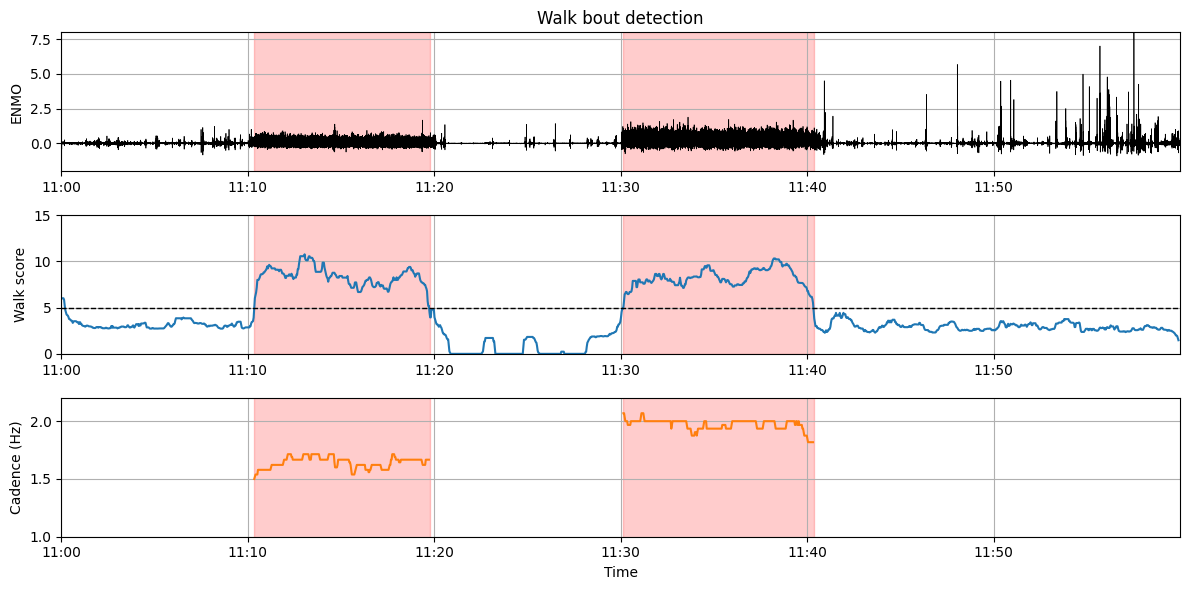

In [ ]:
fig, ax = plt.subplots(3,1)
ax[0].set_title("Walk bout detection")

# Figure options
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax[0].set_xlim(df.index[0], df.index[-1])
ax[1].set_xlim(df.index[0], df.index[-1])
ax[2].set_xlim(df.index[0], df.index[-1])

ax[0].grid()
ax[1].grid()
ax[2].grid()

# Plotting total acceleration (ENMO)
ax[0].set_ylim(-2,8)
ax[0].set_ylabel("ENMO")
ax[0].plot(df.index, df.accel, c="k", linewidth=0.5)
for w in bouts:
    ax[0].fill_between((t_datetime[w[0]], t_datetime[w[1]]), -2, 8, alpha=0.2, color="r")

# Plotting walk score
ax[1].set_ylim(0,15)
ax[1].set_ylabel("Walk score")
ax[1].plot(t_datetime, scores, c="tab:blue")
ax[1].axhline(5, linestyle="--", color="k", linewidth=1)
for w in bouts:
    ax[1].fill_between((t_datetime[w[0]], t_datetime[w[1]]), 0, 15, alpha=0.2, color="r")

# Plotting cadence during each walk bout
ax[2].set_ylim(1.0,2.2)
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Cadence (Hz)")
for w in bouts:
    ax[2].fill_between((t_datetime[w[0]], t_datetime[w[1]]), 0.5, 2.5, alpha=0.2, color="r")
    ax[2].plot(t_datetime[w[0]:w[1]], f0[w[0]:w[1]], color="tab:orange")


fig.set_size_inches(12,6)
fig.tight_layout()
plt.show()

For downstream predictions, we can compute summary statistics of the walk bouts to use as potential predictors. Here are some examples:

`walk_fraction`: proportion of time spent walking

`num_bouts`: total number of walk bouts

`bout_length_median`: median length (s) of a walk bout

`bout_length_logstd`: standard deviation of the log(length) of the walk bouts -- may require several bouts to be robustly estimated

`cadence_median`: median cadence (Hz) of all walking

`cadence_log_std`: standard deviation of the log(cadence) of all walking

In [ ]:
bout_lengths = t[bouts[:,1]] - t[bouts[:,0]]
f0_array = f0[mask]
f0_array = f0_array[~np.isnan(f0_array)]

predictors = {
    "walk_fraction": np.mean(mask),
    "num_bouts": len(bouts),
    "bout_length_median": np.median(bout_lengths) if bout_lengths.size > 0 else np.nan,
    "bout_length_logstd": np.std(np.log(bout_lengths), ddof=1) if bout_lengths.size > 0 else np.nan,
    "cadence_median": np.median(f0_array) if f0_array.size > 0 else np.nan,
    "cadence_logstd": np.std(np.log(f0_array), ddof=1) if f0_array.size > 0 else np.nan,
}

Here is an example dataframe entry for this actigraphy sample.

In [11]:
final_df = pd.DataFrame.from_records([predictors])
final_df

,walk_fraction,num_bouts,bout_length_median,bout_length_logstd,cadence_median,cadence_logstd
0,0.327394,2,588.0,0.057755,1.875,0.094647
